# Part 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import chisquare
from scipy.stats import chi2
from scipy.linalg import expm
from scipy.stats import kstest

## Task 7

In [12]:
random.seed(42)
np.random.seed(42)

Q = np.array([
    [-0.0085, 0.005,  0.0025, 0,     0.001],
    [0,      -0.014,  0.005,  0.004, 0.005],
    [0,       0,     -0.008,  0.003, 0.005],
    [0,       0,      0,     -0.009, 0.009],
    [0,       0,      0,      0,     0]      # absorbing
])

def simulate_one_ctmc_with_distant(Q, start_state=1):
    state = start_state
    time = 0.0
    time_to_first_distant = np.nan  # <--- ændret fra None

    while state != 4:
        rate = -Q[state, state]
        wait = np.random.exponential(1 / rate)
        time += wait

        probs = Q[state].copy()
        probs[state] = 0
        probs = probs / rate

        next_state = np.random.choice(len(Q), p=probs)

        if next_state == 2 and np.isnan(time_to_first_distant):
            time_to_first_distant = time

        state = next_state

    return time, time_to_first_distant


In [16]:
random.seed(42)
np.random.seed(42)

n = 1000

lifetimes = []
distant_times = []

for _ in range(n):
    t, t_dist = simulate_one_ctmc_with_distant(Q)
    lifetimes.append(t)
    distant_times.append(t_dist)

lifetimes = np.array(lifetimes)
distant_times = np.array(distant_times)


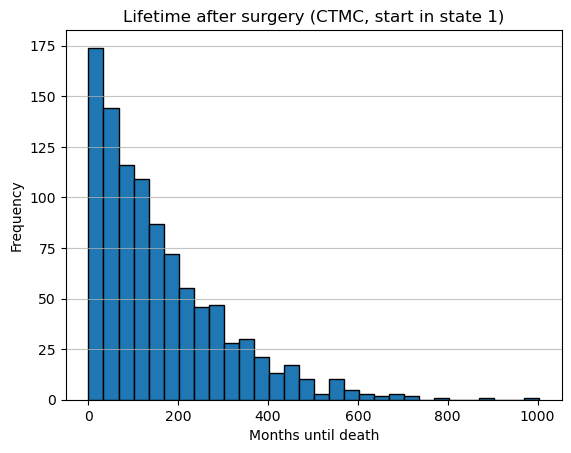

Mean lifetime: 160.95 months
95% CI for mean: (152.00, 169.91)
Standard deviation: 144.46 months
95% CI for sd: (138.39, 151.09)


In [17]:
random.seed(42)
np.random.seed(42)

# histogram
plt.hist(lifetimes, bins=30, edgecolor='black')
plt.title('Lifetime after surgery (CTMC, start in state 1)')
plt.xlabel('Months until death')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# mean + 95% CI
mean_life = lifetimes.mean()
sd_life = lifetimes.std(ddof=1)
se_mean = sd_life / np.sqrt(n)

ci_mean_lower = mean_life - 1.96 * se_mean
ci_mean_upper = mean_life + 1.96 * se_mean

print(f"Mean lifetime: {mean_life:.2f} months")
print(f"95% CI for mean: ({ci_mean_lower:.2f}, {ci_mean_upper:.2f})")

# sd + 95% CI via chi-square
df = n - 1
chi2_lower = chi2.ppf(0.975, df)
chi2_upper = chi2.ppf(0.025, df)

sd_lower = np.sqrt(df * sd_life**2 / chi2_lower)
sd_upper = np.sqrt(df * sd_life**2 / chi2_upper)

print(f"Standard deviation: {sd_life:.2f} months")
print(f"95% CI for sd: ({sd_lower:.2f}, {sd_upper:.2f})")


In [18]:
random.seed(42)
np.random.seed(42)

threshold = 30.5

# kun dem der faktisk får distant recurrence
has_distant = ~np.isnan(distant_times)

# blandt alle 1000: distant recurrence senest 30.5 måneder
n_distant_by_305 = np.sum((has_distant) & (distant_times <= threshold))
prop_distant_by_305 = n_distant_by_305 / n

print(f"{n_distant_by_305} ud af {n} kvinder ({prop_distant_by_305:.3f}) får distant recurrence senest {threshold} måneder efter operation.")


130 ud af 1000 kvinder (0.130) får distant recurrence senest 30.5 måneder efter operation.


## Task 8

In [23]:
random.seed(42)
np.random.seed(42)

Q = np.array([
    [-0.0085, 0.005,  0.0025, 0,     0.001],
    [0,      -0.014,  0.005,  0.004, 0.005],
    [0,       0,     -0.008,  0.003, 0.005],
    [0,       0,      0,     -0.009, 0.009],
    [0,       0,      0,      0,     0]      # death
])

def simulate_one_ctmc(Q, start_state=1):
    state = start_state
    time = 0.0

    while state != 4:  # 4 = death
        rate = -Q[state, state]
        wait = np.random.exponential(1 / rate)
        time += wait

        probs = Q[state].copy()
        probs[state] = 0
        probs = probs / rate

        next_state = np.random.choice(len(Q), p=probs)
        state = next_state

    return time

def simulate_many_ctmc(Q, n=1000):
    lifetimes = []
    for _ in range(n):
        t = simulate_one_ctmc(Q, start_state=1)
        lifetimes.append(t)
    return np.array(lifetimes)

n = 1000
lifetimes_ctmc = simulate_many_ctmc(Q, n)


KS-statistik: 0.0158
p-værdi:      0.9605


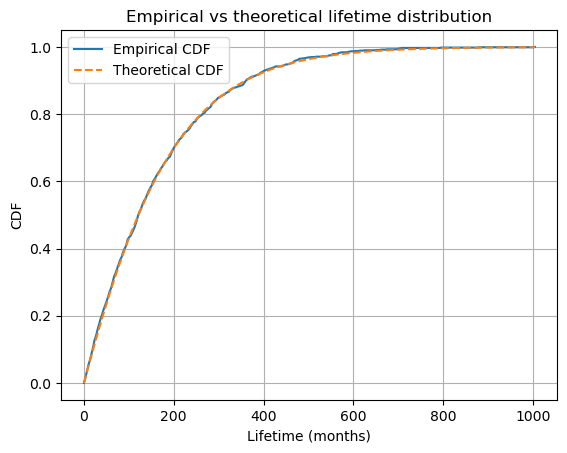

In [29]:
random.seed(42)
np.random.seed(42)
Qs = Q[:-1, :-1]              # submatrix (4x4)
p0 = np.array([0, 1, 0, 0])   # start i state 1
one = np.ones(Qs.shape[0])

def F_T(t):
    t = np.asarray(t)

    # scalar input → return scalar
    if t.ndim == 0:
        M = expm(Qs * float(t))
        return 1 - p0 @ M @ one

    # vector input → return array
    out = np.zeros_like(t, dtype=float)
    for i, ti in enumerate(t):
        M = expm(Qs * ti)
        out[i] = 1 - p0 @ M @ one
    return out

# KS-test
D, p_value = kstest(lifetimes_ctmc, F_T)
print(f"KS-statistik: {D:.4f}")
print(f"p-værdi:      {p_value:.4f}")

# Empirisk vs teoretisk CDF
ts = np.linspace(0, lifetimes_ctmc.max(), 300)
F_emp = np.array([np.mean(lifetimes_ctmc <= t) for t in ts])
F_th  = np.array([F_T(t) for t in ts])

plt.plot(ts, F_emp, label='Empirical CDF')
plt.plot(ts, F_th, '--', label='Theoretical CDF')
plt.xlabel('Lifetime (months)')
plt.ylabel('CDF')
plt.title('Empirical vs theoretical lifetime distribution')
plt.legend()
plt.grid(True)
plt.show()


## Part 9

In [8]:
np.random.seed(42)
def simulate_ctmc(Q, n):
    lts = np.zeros(n)
    for i in range(n):
        state = 0
        time = 0.0
        while state != 4:
            rate = -Q[state, state]
            wait = np.random.exponential(1 / rate)
            time += wait

            probs = Q[state].copy()
            probs[state] = 0
            probs = probs / rate

            next_state = np.random.choice(len(Q), p=probs)
            state = next_state
        lts[i] = time
    return lts

def kaplan_meier(times):
    times = np.sort(times)
    surv = 1- np.arange(1, len(times)+1) / len(times)
    return np.concatenate(([0], times)), np.concatenate(([1], surv))

Q_original = np.array([
    [-0.00475, 0.0025,   0.00125, 0,      0.001],
    [0,       -0.007,    0,       0.002,  0.005],
    [0,        0,       -0.008,   0.003,  0.005],
    [0,        0,        0,      -0.009,  0.009],
    [0,        0,        0,       0,      0]
])

Q_treat = np.array([
    [0,       0.0025, 0.00125, 0,      0.001],
    [0,       0,      0,       0.002,  0.005],
    [0,       0,      0,       0.003,  0.005],
    [0,       0,      0,       0,      0.009],
    [0,       0,      0,       0,      0]
], dtype=float)

for i in range(5):
    Q_treat[i, i] = -np.sum(Q_treat[i, Q_treat[i] > 0])

N = 1000
times_original = [simulate_ctmc(Q_original, N) for _ in range(N)]
times_treat    = [simulate_ctmc(Q_treat, N)    for _ in range(N)]

t_o, S_o = kaplan_meier(times_original)
t_t, S_t = kaplan_meier(times_treat)

plt.figure(figsize=(10,6))
plt.step(t_o, S_o, where="post", label="Uden behandling", linewidth=2)
plt.step(t_t, S_t, where="post", label="Med behandling", linewidth=2)

plt.xlabel("Tid (måneder)")
plt.ylabel("Survival S(t)")
plt.title("Kaplan–Meier survival: behandling vs. ingen behandling")
plt.legend()
plt.grid(True)
plt.show()


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 1 has 2 dimension(s)

In [5]:
Q_treat

array([[-0.00475,  0.0025 ,  0.00125,  0.     ,  0.001  ],
       [ 0.     , -0.007  ,  0.     ,  0.002  ,  0.005  ],
       [ 0.     ,  0.     , -0.008  ,  0.003  ,  0.005  ],
       [ 0.     ,  0.     ,  0.     , -0.009  ,  0.009  ],
       [ 0.     ,  0.     ,  0.     ,  0.     , -0.     ]])